In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
# Load dataset
df = pd.read_csv('C:/Users/joshd/Documents/ML Project Sem-7/product_wise_sales.csv')


# Clean data: Fill NaNs with 0 for revenue columns
revenue_cols = ['Revenue (FY 2025)', 'Revenue (FY 2024)', 'Revenue (FY 2023)']
df[revenue_cols] = df[revenue_cols].fillna(0)

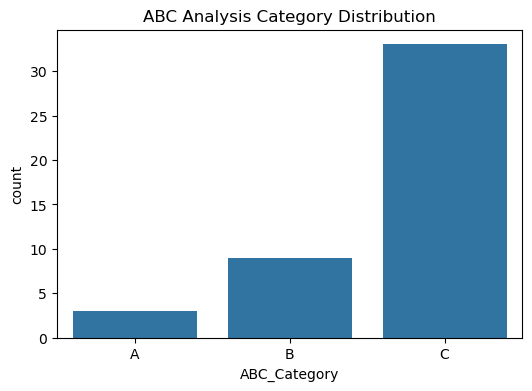

In [3]:
df['Revenue_FY2025'] = df['Revenue (FY 2025)']
df = df.sort_values(by='Revenue_FY2025', ascending=False)
df['Cumulative %'] = df['Revenue_FY2025'].cumsum() / df['Revenue_FY2025'].sum() * 100


def abc_category(x):
    if x <= 70:
        return 'A'
    elif x <= 90:
        return 'B'
    else:
        return 'C'


df['ABC_Category'] = df['Cumulative %'].apply(abc_category)

# Plot ABC distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='ABC_Category', data=df, order=['A', 'B', 'C'])
plt.title('ABC Analysis Category Distribution')
plt.show()

c:\Users\Admin\anaconda3\envs\dppl_project\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\Admin\anaconda3\envs\dppl_project\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


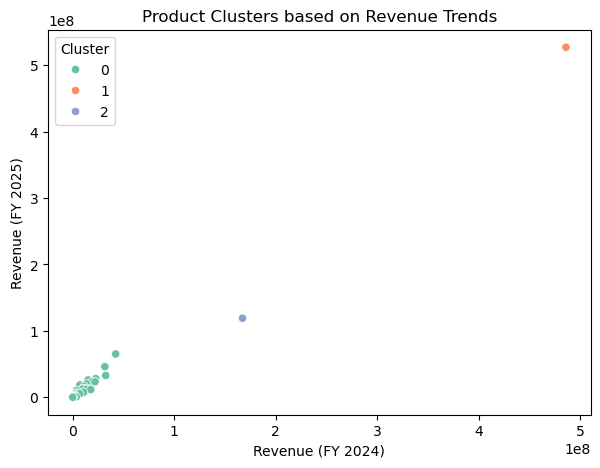

In [4]:
X = df[revenue_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)


# Plot Clusters
plt.figure(figsize=(7, 5))
sns.scatterplot(x='Revenue (FY 2024)', y='Revenue (FY 2025)', hue='Cluster', data=df, palette='Set2')
plt.title('Product Clusters based on Revenue Trends')
plt.show()

In [5]:
df['Growth_2024'] = ((df['Revenue (FY 2024)'] - df['Revenue (FY 2023)']) / (df['Revenue (FY 2023)'] + 1)) * 100
df['Growth_2025'] = ((df['Revenue (FY 2025)'] - df['Revenue (FY 2024)']) / (df['Revenue (FY 2024)'] + 1)) * 100


# Top 5 growing products in 2025
print("Top 5 Products by Growth in 2025:")
print(df[['Product', 'Growth_2025']].sort_values(by='Growth_2025', ascending=False).head())

Top 5 Products by Growth in 2025:
                       Product   Growth_2025
22       SQ 4 LTR CONTAINER FG  1.383377e+08
17  RTC 500 HALDIRAM BHEL - FG  5.827500e+07
2                  HX 500 - FG  3.070400e+07
1                  HX 250 - FG  2.007500e+07
27                      Labels  3.035185e+03


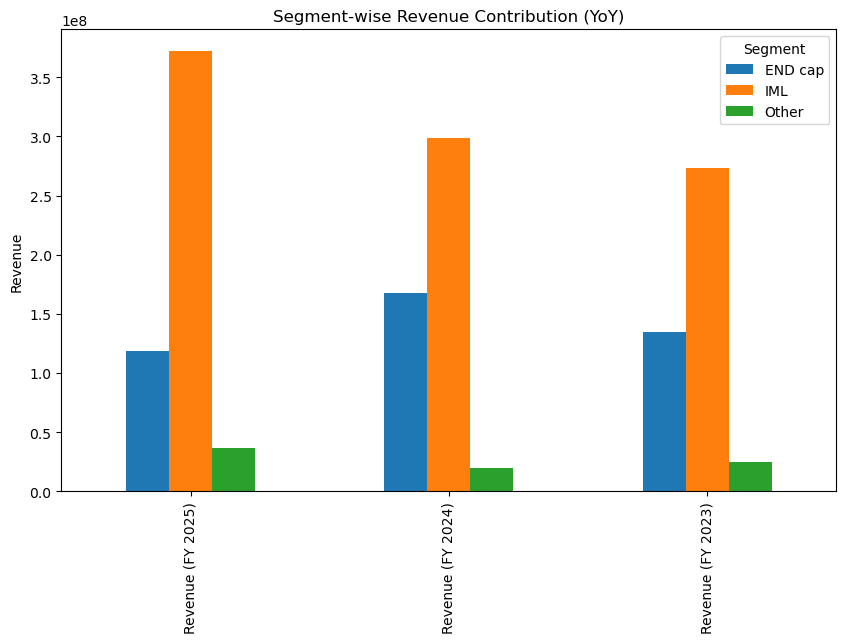

In [6]:
segment_trend = df.groupby('Segment')[revenue_cols].sum()
segment_trend.T.plot(kind='bar', figsize=(10, 6))
plt.title('Segment-wise Revenue Contribution (YoY)')
plt.ylabel('Revenue')
plt.show()

In [7]:
# Save updated data with ABC & Cluster info
df.to_csv('C:/Users/joshd/Documents/ML Project Sem-7/SKU_analysis_results.csv', index=False)
print('✅ Analysis completed and results saved as SKU_analysis_results.csv')

✅ Analysis completed and results saved as SKU_analysis_results.csv


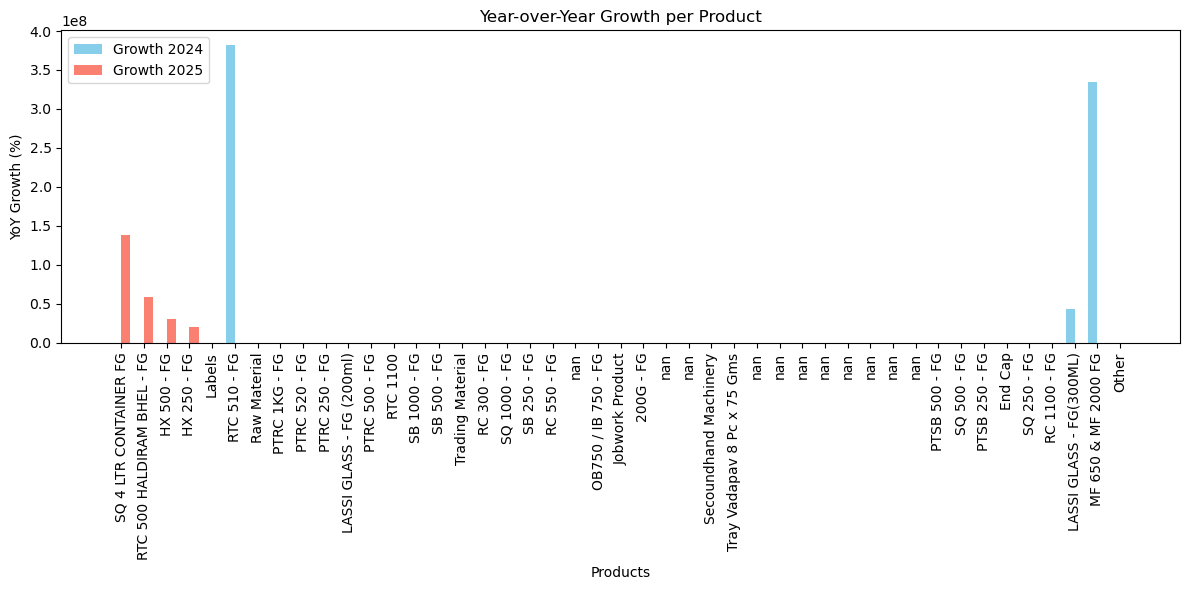

In [8]:
plt.figure(figsize=(12, 6))

# Sort products by Growth_2025 for better visualization
df_sorted = df.sort_values(by='Growth_2025', ascending=False)

# Barplot for YoY Growth 2024 and 2025
bar_width = 0.4
index = np.arange(len(df_sorted))

plt.bar(index, df_sorted['Growth_2024'], width=bar_width, label='Growth 2024', color='skyblue')
plt.bar(index + bar_width, df_sorted['Growth_2025'], width=bar_width, label='Growth 2025', color='salmon')

plt.xticks(index + bar_width / 2, df_sorted['Product'], rotation=90)
plt.xlabel('Products')
plt.ylabel('YoY Growth (%)')
plt.title('Year-over-Year Growth per Product')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_21768\149760989.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Growth_2025', y='Product', data=top5, palette='Greens_r')


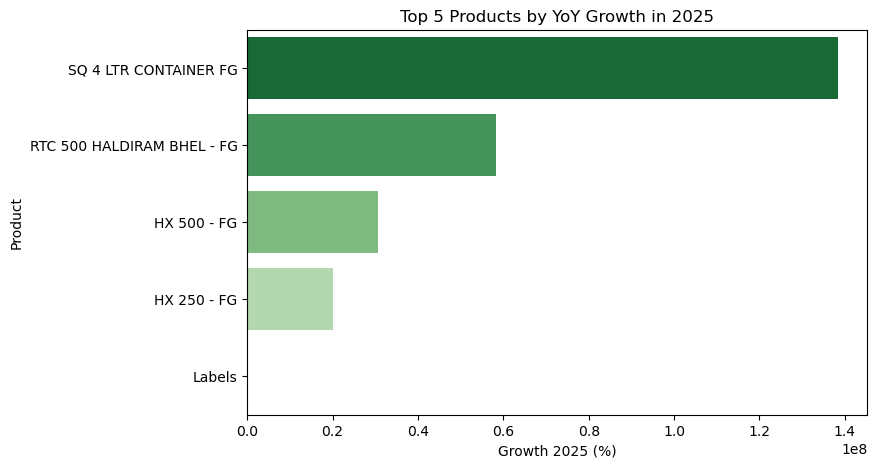

In [9]:
top5 = df_sorted.head(5)
plt.figure(figsize=(8, 5))
sns.barplot(x='Growth_2025', y='Product', data=top5, palette='Greens_r')
plt.xlabel('Growth 2025 (%)')
plt.ylabel('Product')
plt.title('Top 5 Products by YoY Growth in 2025')
plt.show()

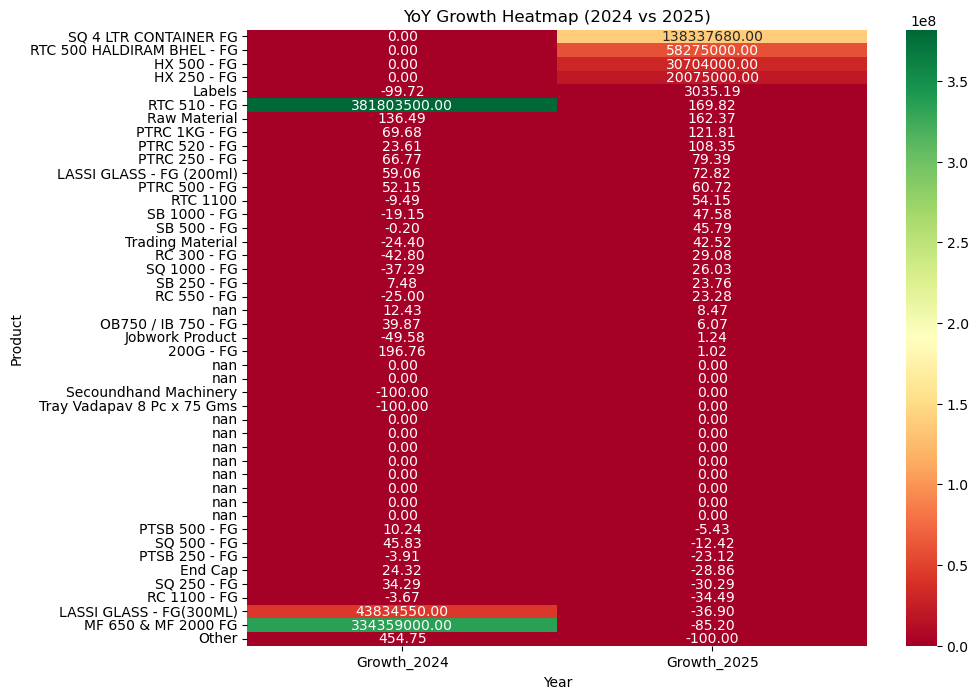

In [10]:
growth_cols = ['Growth_2024', 'Growth_2025']
plt.figure(figsize=(10, 8))
sns.heatmap(df_sorted[growth_cols], annot=True, fmt=".2f", cmap='RdYlGn', yticklabels=df_sorted['Product'])
plt.title('YoY Growth Heatmap (2024 vs 2025)')
plt.xlabel('Year')
plt.ylabel('Product')
plt.show()